# SEDアノマリ評価、有意度評価起点
# --- TO DO ---
### Resisual Distribution: Check (Is it a Gaussian?)
 - K-S test
(sensitive to mode )
 - Anderson Darling
(Sensitive to tail)
### Resisual Distribution: Maybe a heat map?

### Detected peaks Distribution by simulation
 - Simulating SEDs (Residuals) based on the numbers of obs with the given data points,
 - which could be multiplied to around 1000 observations
 - Detect the peaks
 - Repeat 1000 times
 - Obtain the distribution of the number of detected peak

### Grant result


### The models in the Mrk501 'bump' paper

### Start Paper draft
 - Overleaf



# --- 実データ適用編：評価 ---

## 各SEDのbin数
### -> 重みづけ込みの確率算出
異なるbin数による確率の違いをテーブルにする。
各bin数で理論・計算での整合性を確認する。
実際のSEDは各々異なるbin数なので、確率テーブルを使って重みづけ計算する。



## 各データ点の residual vs.energy 分布
### -> そのまま
### -> 上限を揃えたらどうなる？


## chi2 vs. fitted parameter
Hardな方がフィットしづらくなったり？










# --- 実データ適用編：異常発見 ---
## Sudden drop

## LEでの急減少


# --- コード開発 ---
## Probability table generation

15 bins from 8 to 22


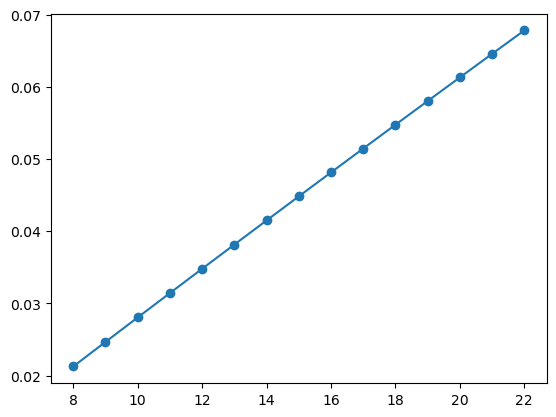

In [ ]:
import numpy as np
# p=(1-0.95)/2.0
nbinsmin=9
nbinsmax=22
p=(1-0.68)/2.0
P=np.array([[1-p,p,0,0],[1-p,0,p,0],[1-p,0,0,p],[0,0,0,1]])
A=np.matrix(P)
probs = []
for ibins in range(nbinsmin, nbinsmax+1):
  B=A**ibins
  probs.append(B[0,3])

print(len(probs), "bins from", nbinsmin, "to", nbinsmax)
import matplotlib.pyplot as plt
plt.plot(range(nbinsmin, nbinsmax+1), probs, marker='o')

## Peak detection

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u
from scipy.optimize import curve_fit


nconsecutive = 3
def get_consecutive_bins(s,nconsecutive ):

  for i in range(0,len(s)-nconsecutive+1):
  # for i in range(0,len(s)-nconsecutive):
      if np.all(s[i:i+nconsecutive] > 1):
        #   print(i)
        #   print(s[i:i+nconsecutive])
        #   print('---')
          return i
      
  return -1

def gaussian(x, amplitude, mu, sigma):
    # return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2) : Normal distribution
    return amplitude * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def eval_spectra(filepath): #'data/3C454.3_allsed_14d_min11.ecsv'
  # logpar_init = LogParabola1D(amplitude=1,x_0=10,alpha=1,beta=1)
  logpar_init = LogParabola1D(
    amplitude = 0.000016494113774149846,
    x_0 = 9.482855296727278,
    alpha = -0.5677548858840729,
    beta = 0.1071613245072173)

  ### initialize a linear fitter ###
  # fit = fitting.TRFLSQFitter()
  fit = fitting.DogBoxLSQFitter()

  ### Read the data ###
  t0 = Table.read(filepath)
  nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
  t = t0[nonzero_mask]

  ### MJDごとに処理 ###
  obsdates=np.unique(t['tstart'].data).tolist()
  n_detected_peaks = 0
  array_nbins = []
  t_residual = Table()
  for idx, obsdate in enumerate(obsdates):
    # print(idx, ': obsdate',obsdate)
    mask = (t['tstart']==obsdate)
    x = t[mask]['e_ref']
    y = t[mask]['e2dnde']
    yerr = t[mask]['e2dnde_err']
    ### fit the data with the fitter ###
    # logpar_init.amplitude.value=x[1]*1.0e-8
    fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
    residuals = (y-fitted_line(x))/yerr
    # residuals = (fitted_line(x)-y)/yerr # negative:dip finding
    peakbininit = get_consecutive_bins(residuals,nconsecutive)
    nbins = len(x)
    if nbins < nbinsmin:
        print('nbins < nbinsmin:',nbins)
        continue
    array_nbins.append(nbins)
    t_residual_ind = Table([x, residuals,np.full(len(x),obsdate)], names=[ "e_ref", "residual", "obsdate"])#"e_ref",x, "residual", residuals, "e2dnde", y, "e2dnde_err", yerr)
    t_residual = vstack([t_residual,t_residual_ind])
    if peakbininit > 0:
        # print('peakbininit',peakbininit)
        plt.errorbar(x,y,yerr=yerr, marker='o',linestyle='')
        plt.plot(x,fitted_line(x),'-')
        plt.plot(x[peakbininit:peakbininit+nconsecutive],
                y[peakbininit:peakbininit+nconsecutive], label='obs'+str(idx), marker='x',linestyle='-')
        n_detected_peaks += 1
        plt.title('obs'+str(idx)+':MJD'+str(int(obsdate)))
        plt.xlabel('Energy [MeV]')
        plt.ylabel('E^2 dN/dE [MeV cm^-2 s^-1]')
        plt.xscale('log')
        plt.yscale('log')
        plt.show()

  ### bin数分布 ###
  hist_nbins = plt.hist(array_nbins, bins=np.arange(nbinsmin-0.5, nbinsmax+1.5, 1), histtype='step', lw=2)
  plt.xlabel('Number of effective bins')
  plt.ylabel('Number of SEDs')
  plt.show()

  ### 各Eの residual 分布 ###
  plt.plot(t_residual['e_ref'], t_residual['residual'],'.')
  # plt.hist2d(t_residual['e_ref'], t_residual['residual'], bins=20, cmap='Blues')
  plt.xscale('log')
  plt.show()

  
  ### residual 分布 ###
  # plt.hist(t_residual['residual'], bins = 30)
  # plt.yscale('log')  
  # plt.show()
  n, bins, patches =plt.hist(t_residual['residual'], bins=np.arange(-5,5,0.2), histtype='step')
  # plt.show()

  # Fit a gaussian distribution to the data:
  xmin, xmax = plt.xlim()
  x = np.linspace(xmin, xmax, len(bins)-1)
  y = n
  popt, pcov = curve_fit(gaussian, x, y, p0=[1, np.mean(x), np.std(x)])
  # popt, pcov = curve_fit(gaussian, x, y)

  plt.plot(x, gaussian(x, *popt))#, 'k', linewidth=2)
  ymin, ymax = plt.ylim()
  plt.ylim(0.8,ymax)
  print('amplitude', popt[0])
  print('mu', popt[1])
  print('sigma', popt[2])
  plt.yscale('log')
  plt.show()

  # energies = np.unique(t_residual['e_ref'].data).tolist()
  # for energy in energies: 
  #   mask = (t_residual['e_ref']== energy)
  #   plt.hist(t_residual[mask]['residual'], bins=np.arange(-5,5,0.2), histtype='step')
  #   plt.show()


  print('Number of detected peaks:',n_detected_peaks)
  print('Number of used SEDs:',len(array_nbins))
  print('Number of SEDs:',len(obsdates))
  print('Weighted average of the probability from theory: ', np.sum(np.multiply(hist_nbins[0],probs))/len(array_nbins))

## SED表示

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u
from scipy.optimize import curve_fit

def show_SED(filepath,target_MJD, range_days): #'data/3C454.3_allsed_14d_min11.ecsv'
  # logpar_init = LogParabola1D(amplitude=1,x_0=10,alpha=1,beta=1)
  logpar_init = LogParabola1D(
    amplitude = 0.000016494113774149846,
    x_0 = 9.482855296727278,
    alpha = -0.5677548858840729,
    beta = 0.1071613245072173)

  ### initialize a linear fitter ###
  # fit = fitting.TRFLSQFitter()
  fit = fitting.DogBoxLSQFitter()
  
  ### Read the data ###
  t0 = Table.read(filepath)
  nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
  t = t0[nonzero_mask]

  ### MJDごとに処理 ###
  obsdates=np.unique(t['tstart'].data).tolist()
  n_detected_peaks = 0
  array_nbins = []
  t_residual = Table()
  for obsdate in obsdates:
    if obsdate < target_MJD - range_days or obsdate > target_MJD + range_days:
      continue
    # print(idx, ': obsdate',obsdate)
    mask = (t['tstart']==obsdate)
    x = t[mask]['e_ref']
    y = t[mask]['e2dnde']
    yerr = t[mask]['e2dnde_err']
    fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
    residuals = (y-fitted_line(x))/yerr    
    plt.errorbar(x,y,yerr=yerr, marker='o',linestyle='')
    plt.plot(x,fitted_line(x),'-')
    # plt.plot(x[peakbininit:peakbininit+nconsecutive],
    #         y[peakbininit:peakbininit+nconsecutive], label='obs'+str(idx), marker='x',linestyle='-')
    n_detected_peaks += 1
    plt.title('MJD'+str(int(obsdate)))
    plt.xlabel('Energy [MeV]')
    plt.ylabel('E^2 dN/dE [MeV cm^-2 s^-1]')
    plt.xscale('log')
    plt.yscale('log')
    plt.show()


In [172]:
# show_SED('data/3C454.3_allsed_1d_2_min11.ecsv', 56830, 5) # show SEDs around MJD 56830

# --- 評価 ---

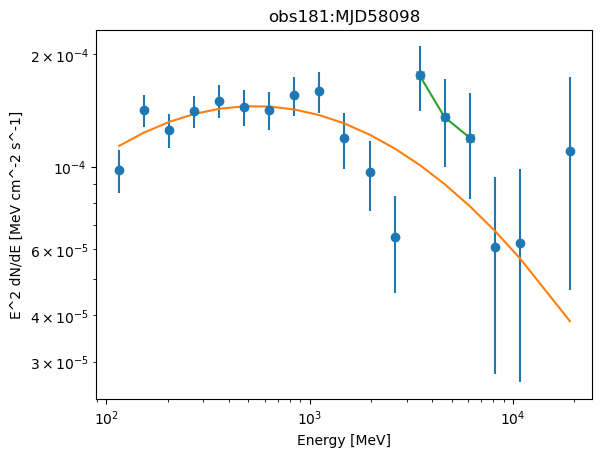

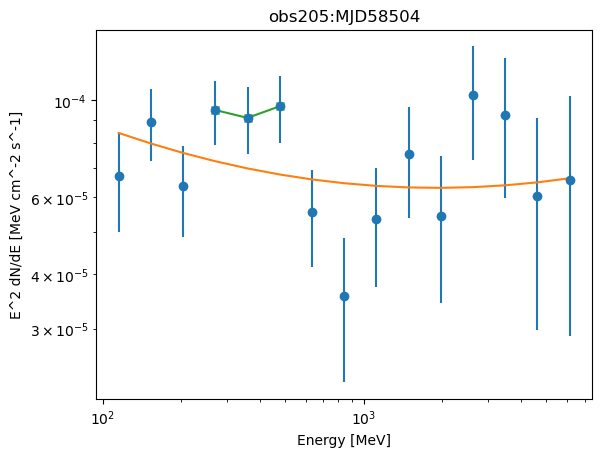

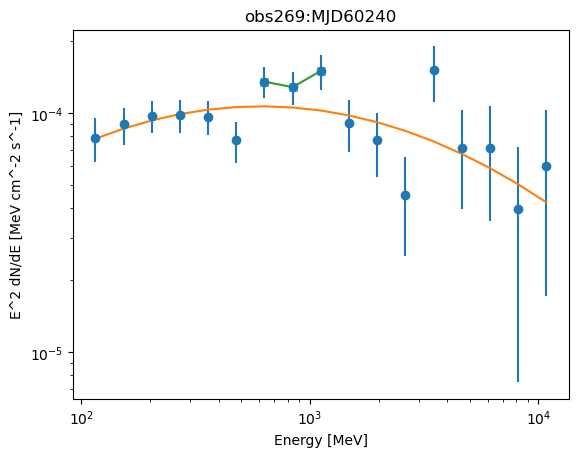

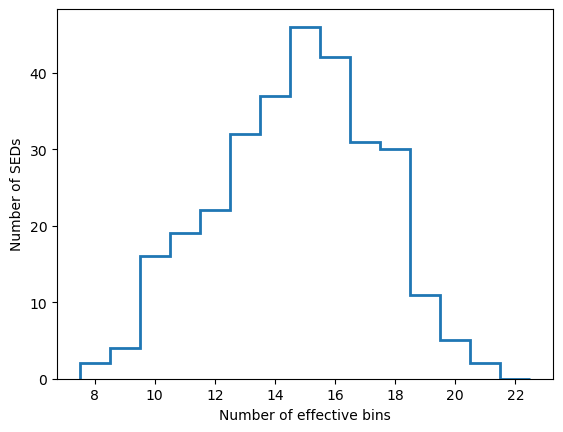

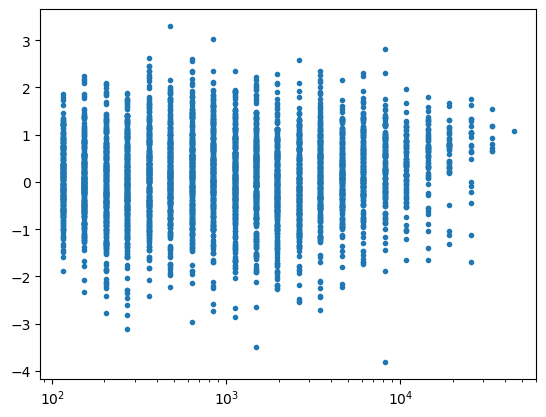

amplitudeIntel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions. 413.539298119518
mu 0.15596415032157235
sigma -0.9457521924351685



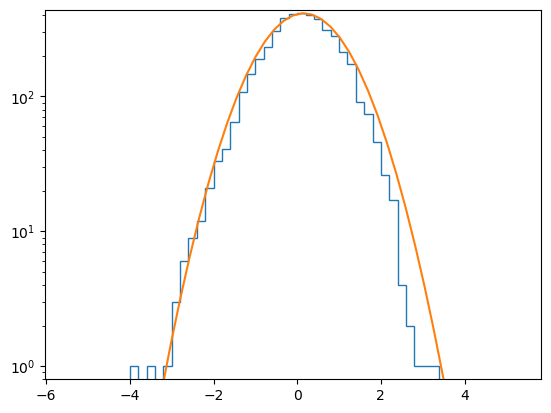

Number of detected peaks: 3
Number of used SEDs: 299
Number of SEDs: 299
Weighted average of the probability from theory:  0.04383427636702541


In [67]:
# eval_spectra('data/3C454.3_allsed_14d_min11.ecsv')  # 2pos, 0neg/264
# eval_spectra('data/3C454.3_allsed_7d_min11.ecsv')   # 3pos, 0neg/208
# eval_spectra('data/3C454.3_allsed_1d_min11.ecsv')   # 8pos, 0neg/556
# eval_spectra('data/3C454.3_allsed_1d_2_min11.ecsv') # 7pos, 0neg/461, several peaks on 56830, sudden drop on 57562

# show_SED('data/3C454.3_allsed_1d_2_min11.ecsv', 56830, 5) # show SEDs around MJD 56830
# show_SED('data/3C454.3_allsed_1d_2_min11.ecsv', 57562, 5) # show SEDs around MJD 57562


# eval_spectra('data/Mrk421_allsed_14d_min11.ecsv')   # 6pos, 1neg/394
# eval_spectra('data/CTA102_allsed_14d_min11.ecsv')   # 5pos, 1neg/180, too low in lowestE on 57790
# show_SED('data/CTA102_allsed_14d_min11.ecsv', 57790, 20) # show SEDs around MJD 57790
# eval_spectra('data/3C279_allsed_14d_min11.ecsv')    # 6pos, 0neg/260
# eval_spectra('data/4C+21.35_allsed_14d_min11.ecsv') # 0pos, 0neg /101
# eval_spectra('data/BLLac_allsed_14d_min11.ecsv')    # 5pos, 0neg/249　-> 3pos, 0neg/294
# eval_spectra('data/PKS1510-089_allsed_14d_min11.ecsv') # 2pos, 0neg/214
# eval_spectra('data/S20109+22_allsed_14d_min11.ecsv') # 0/50
# eval_spectra('data/S50716+71_allsed_14d_min11.ecsv')    # 4pos, 0neg/278
eval_spectra('data/PKS1424-41_allsed_14d_min11.ecsv')    # 3pos, 0neg/297